In [23]:
# Cell 1 — Imports and API setup
import requests
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import entropy
from fredapi import Fred

FRED_KEY = "9e67dd28060675ec071dfaa9f650840f"
BEA_KEY  = "5073F933-9D7B-4BB4-ACBB-D59A653AD16C"
fred = Fred(api_key=FRED_KEY)

# Episode definitions — pre-registered before touching results
# Type determines whether we expect CSD signal (endogenous) or not (exogenous)
EPISODES = {
    '2008': {
        'years': ['2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009'],
        'crisis_start': 2007.5,
        'crisis_end': 2009.5,
        'type': 'endogenous_fold',
        'expect_signal': True,
        'label': '2008 GFC'
    },
    '2020': {
        'years': ['2015', '2016', '2017', '2018', '2019', '2020', '2021'],
        'crisis_start': 2020.0,
        'crisis_end': 2020.75,
        'type': 'exogenous_shock',
        'expect_signal': False,
        'label': '2020 COVID (negative control)'
    },
}

# Calm periods for false positive analysis
CALM_PERIODS = {
    'post_gfc_recovery': list(range(2010, 2015)),
    'pre_covid_expansion': list(range(2015, 2020)),
}

print("Episodes pre-registered:")
for ep, cfg in EPISODES.items():
    signal = 'EXPECT signal' if cfg['expect_signal'] else 'EXPECT NO signal'
    print(f"  {cfg['label']} ({cfg['type']}) — {signal}")

print("\nCalm periods for false positive analysis:")
for name, years in CALM_PERIODS.items():
    print(f"  {name}: {years[0]}-{years[-1]}")

print("\nLibraries loaded and APIs connected.")

Episodes pre-registered:
  2008 GFC (endogenous_fold) — EXPECT signal
  2020 COVID (negative control) (exogenous_shock) — EXPECT NO signal

Calm periods for false positive analysis:
  post_gfc_recovery: 2010-2014
  pre_covid_expansion: 2015-2019

Libraries loaded and APIs connected.


In [24]:
# Cell 2 — BEA data pull function
# NOTE: normalized to technical coefficients (column-normalized)
# not raw dollar flows, to remove nominal GDP/inflation effects
def get_bea_flows(year, bea_key):
    url = "https://apps.bea.gov/api/data"
    params = {
        "UserID": bea_key,
        "method": "GetData",
        "DataSetName": "InputOutput",
        "TableID": "259",
        "Year": str(year),
        "ResultFormat": "JSON"
    }
    response = requests.get(url, params=params)
    data = response.json()
    rows = data['BEAAPI']['Results'][0]['Data']
    df = pd.DataFrame(rows)
    df['DataValue'] = pd.to_numeric(df['DataValue'], errors='coerce').fillna(0)
    return df

exclude_cols = ['Total use of products', 'Total industry output',
                'Total intermediate', 'Value added']
exclude_rows = ['Total', 'Value added', 'Compensation', 'Gross operating']

def clean_flows(df):
    flows = df[
        ~df['ColDescr'].isin(exclude_cols) &
        ~df['RowDescr'].str.contains('|'.join(exclude_rows), na=False) &
        (df['DataValue'] > 0)
    ].copy()
    both = set(flows['RowDescr'].unique()) & set(flows['ColDescr'].unique())
    flows = flows[
        flows['RowDescr'].isin(both) &
        flows['ColDescr'].isin(both)
    ].copy()
    # Normalize to technical coefficients: each cell / column total
    # This removes nominal GDP and inflation effects from the network
    col_totals = flows.groupby('ColDescr')['DataValue'].sum()
    flows['weight'] = flows.apply(
        lambda row: row['DataValue'] / col_totals[row['ColDescr']]
        if col_totals[row['ColDescr']] > 0 else 0, axis=1
    )
    return flows

def build_graph(flows):
    G = nx.DiGraph()
    for _, row in flows[flows['weight'] > 0.01].iterrows():
        G.add_edge(row['RowDescr'], row['ColDescr'], weight=row['weight'])
    return G

print("BEA functions defined.")
print("NOTE: normalized to technical coefficients, not raw dollar flows.")

BEA functions defined.
NOTE: normalized to technical coefficients, not raw dollar flows.


In [25]:
# Cell 3 — Pull and compute network metrics for all episodes + calm periods
import os
os.makedirs('../data/processed', exist_ok=True)

def compute_network_metrics(years, label):
    """Compute EBI and spectral gap for a list of years."""
    keystone_over_time = {}
    spectral_gap_over_time = {}
    
    for year in years:
        print(f"  Pulling {year}...", end=' ')
        try:
            df_year = get_bea_flows(year, BEA_KEY)
            flows_year = clean_flows(df_year)
            G_year = build_graph(flows_year)
            
            bet = nx.betweenness_centrality(G_year, weight='weight')
            centrality_df_year = pd.DataFrame({
                'sector': list(bet.keys()),
                'betweenness': list(bet.values()),
            }).sort_values('betweenness', ascending=False)
            keystone_over_time[year] = centrality_df_year
            
            # Spectral gap on technical coefficient matrix
            A = nx.to_numpy_array(G_year)
            eigenvalues = np.sort(np.abs(np.linalg.eigvals(A)))[::-1]
            spectral_gap_over_time[year] = (
                eigenvalues[0] - eigenvalues[1] if len(eigenvalues) > 1 else 0
            )
            print(f"done. Spectral gap: {spectral_gap_over_time[year]:.4f}")
        except Exception as e:
            print(f"FAILED: {e}")
            keystone_over_time[year] = None
            spectral_gap_over_time[year] = None
    
    # Compute EBI for each year
    records = []
    for year in years:
        if keystone_over_time[year] is None:
            continue
        df_y = keystone_over_time[year]
        scores = df_y['betweenness'].values
        scores = scores[scores > 0]
        probs = scores / scores.sum()
        H = entropy(probs)
        top3_share = df_y['betweenness'].nlargest(3).sum() / df_y['betweenness'].sum()
        ebi = H * (1 - top3_share)
        records.append({
            'year': int(year),
            'ebi': ebi,
            'entropy': H,
            'top3_concentration': top3_share,
            'spectral_gap': spectral_gap_over_time[year],
            'episode': label
        })
    
    return pd.DataFrame(records), keystone_over_time

# Pull all episodes
all_metrics = {}
all_keystones = {}

for ep_name, ep_cfg in EPISODES.items():
    print(f"\nPulling episode: {ep_cfg['label']}")
    metrics_df, keystones = compute_network_metrics(ep_cfg['years'], ep_cfg['label'])
    all_metrics[ep_name] = metrics_df
    all_keystones[ep_name] = keystones
    metrics_df.to_csv(f"../data/processed/network_metrics_{ep_name}.csv", index=False)
    print(f"Saved network_metrics_{ep_name}.csv")

# Pull calm periods
print("\nPulling calm periods for false positive analysis...")
calm_metrics = {}
for calm_name, calm_years in CALM_PERIODS.items():
    print(f"\n  {calm_name}")
    str_years = [str(y) for y in calm_years]
    metrics_df, _ = compute_network_metrics(str_years, f'calm_{calm_name}')
    calm_metrics[calm_name] = metrics_df
    metrics_df.to_csv(f"../data/processed/network_metrics_calm_{calm_name}.csv", index=False)
    print(f"  Saved network_metrics_calm_{calm_name}.csv")

print("\nAll data pulled and saved.")


Pulling episode: 2008 GFC
  Pulling 2002... done. Spectral gap: 0.3129
  Pulling 2003... done. Spectral gap: 0.3054
  Pulling 2004... done. Spectral gap: 0.2617
  Pulling 2005... done. Spectral gap: 0.2769
  Pulling 2006... done. Spectral gap: 0.2248
  Pulling 2007... done. Spectral gap: 0.2208
  Pulling 2008... done. Spectral gap: 0.2779
  Pulling 2009... done. Spectral gap: 0.1466
Saved network_metrics_2008.csv

Pulling episode: 2020 COVID (negative control)
  Pulling 2015... done. Spectral gap: 0.1389
  Pulling 2016... done. Spectral gap: 0.1249
  Pulling 2017... done. Spectral gap: 0.1830
  Pulling 2018... done. Spectral gap: 0.2173
  Pulling 2019... done. Spectral gap: 0.1919
  Pulling 2020... done. Spectral gap: 0.1733
  Pulling 2021... done. Spectral gap: 0.1748
Saved network_metrics_2020.csv

Pulling calm periods for false positive analysis...

  post_gfc_recovery
  Pulling 2010... done. Spectral gap: 0.1391
  Pulling 2011... done. Spectral gap: 0.1809
  Pulling 2012... done. 

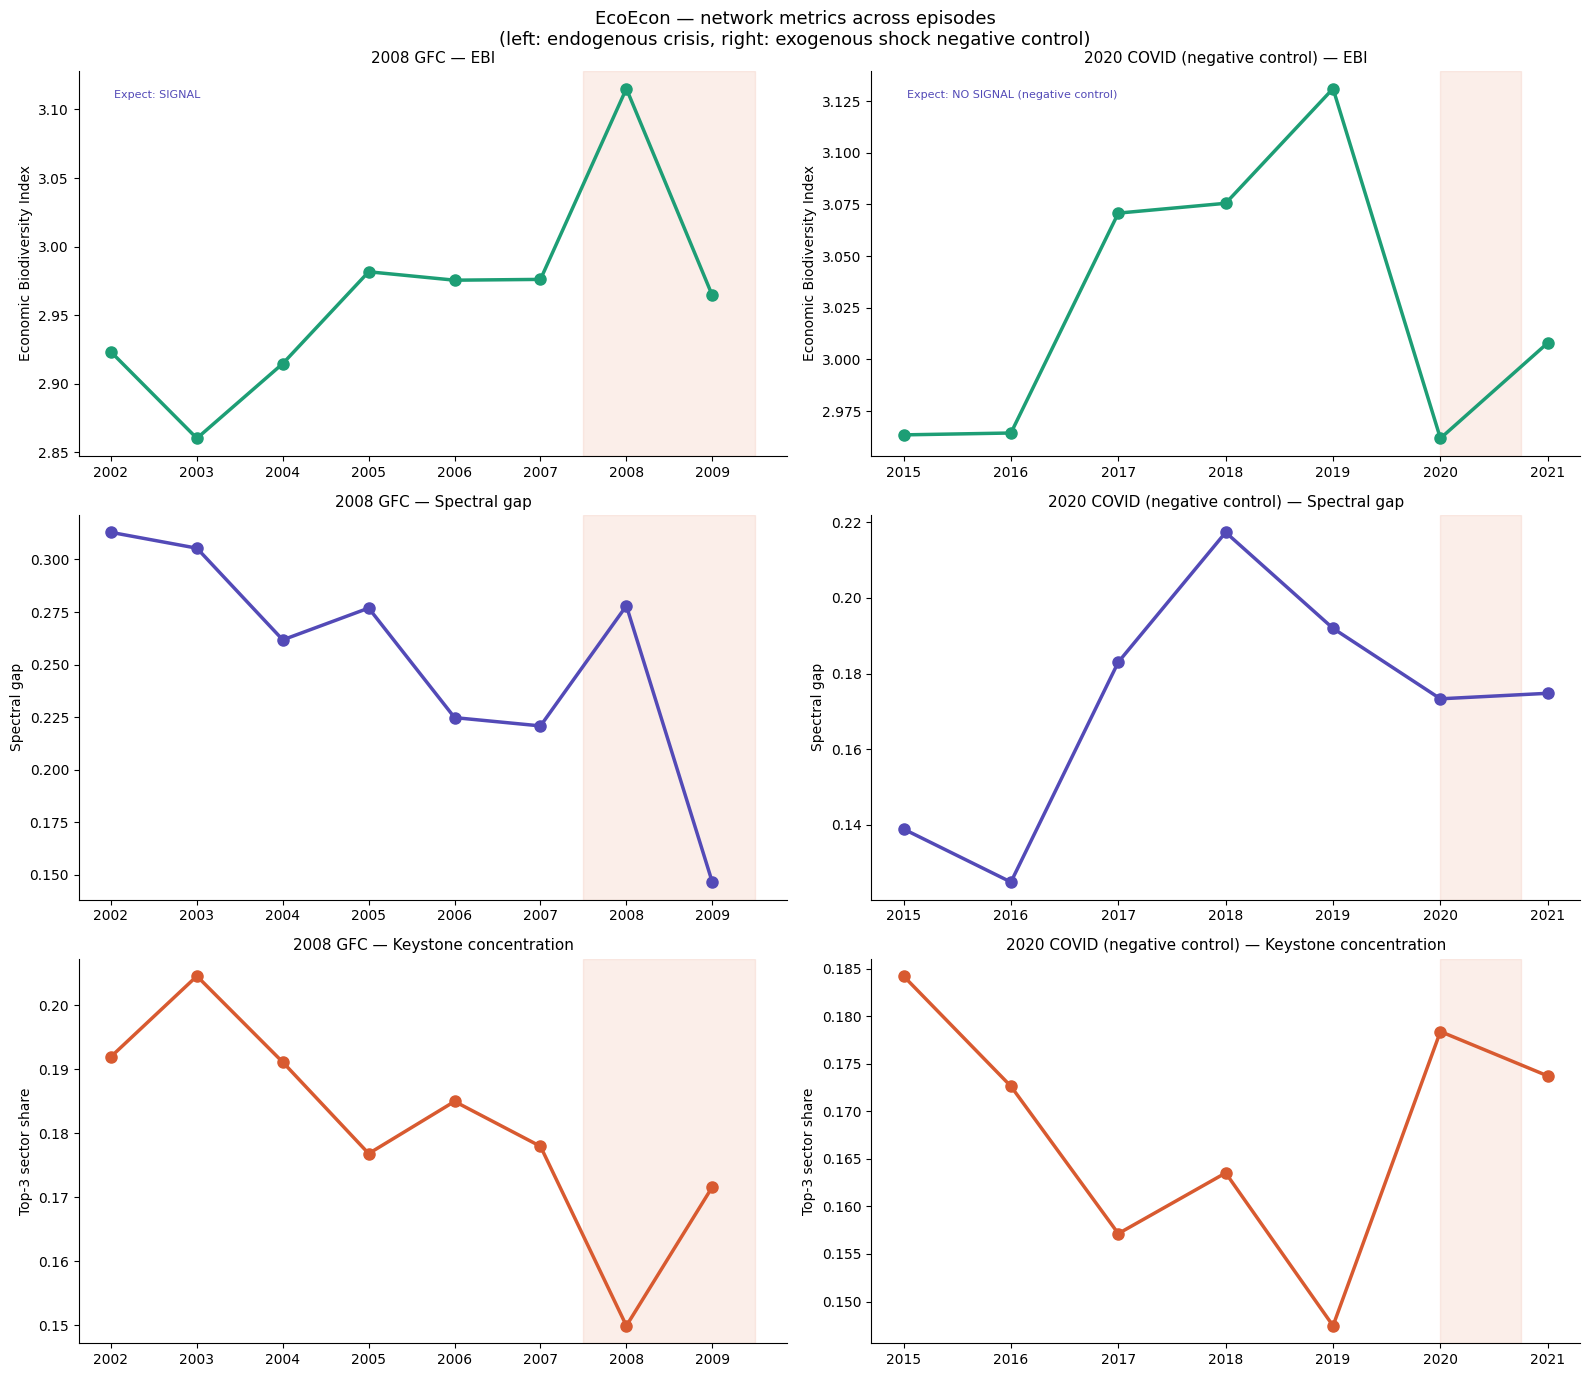

Saved.


In [26]:
# Cell 4 — Plot all episodes side by side
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
metrics_list = [
    ('2008', EPISODES['2008']),
    ('2020', EPISODES['2020']),
]

for col, (ep_name, ep_cfg) in enumerate(metrics_list):
    df = all_metrics[ep_name]
    years_int = df['year'].tolist()
    
    # EBI
    ax1 = axes[0, col]
    ax1.plot(years_int, df['ebi'], color='#1D9E75', linewidth=2.5,
             marker='o', markersize=8, zorder=3)
    ax1.axvspan(ep_cfg['crisis_start'], ep_cfg['crisis_end'],
                alpha=0.10, color='#D85A30')
    ax1.set_title(f"{ep_cfg['label']} — EBI", fontsize=11)
    ax1.set_ylabel('Economic Biodiversity Index')
    signal_txt = "Expect: SIGNAL" if ep_cfg['expect_signal'] else "Expect: NO SIGNAL (negative control)"
    ax1.text(0.05, 0.95, signal_txt, transform=ax1.transAxes,
             fontsize=8, color='#534AB7', va='top')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    
    # Spectral gap
    ax2 = axes[1, col]
    ax2.plot(years_int, df['spectral_gap'], color='#534AB7', linewidth=2.5,
             marker='o', markersize=8, zorder=3)
    ax2.axvspan(ep_cfg['crisis_start'], ep_cfg['crisis_end'],
                alpha=0.10, color='#D85A30')
    ax2.set_title(f"{ep_cfg['label']} — Spectral gap", fontsize=11)
    ax2.set_ylabel('Spectral gap')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    # Top-3 concentration
    ax3 = axes[2, col]
    ax3.plot(years_int, df['top3_concentration'], color='#D85A30', linewidth=2.5,
             marker='o', markersize=8, zorder=3)
    ax3.axvspan(ep_cfg['crisis_start'], ep_cfg['crisis_end'],
                alpha=0.10, color='#D85A30')
    ax3.set_title(f"{ep_cfg['label']} — Keystone concentration", fontsize=11)
    ax3.set_ylabel('Top-3 sector share')
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)

plt.suptitle('EcoEcon — network metrics across episodes\n(left: endogenous crisis, right: exogenous shock negative control)',
             fontsize=13, fontweight='normal')
plt.tight_layout()
plt.savefig('../data/multi_episode_network_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [27]:
# Cell 5 — Keystone sector analysis: does Finance appear before 2008?
print("=== KEYSTONE SECTORS 2006 (pre-crisis peak) ===")
keystones_2006 = all_keystones['2008']['2006']
print(keystones_2006.head(10).to_string(index=False))

print("\n=== KEYSTONE SECTORS 2019 (pre-COVID) ===")
keystones_2019 = all_keystones['2020']['2019']
print(keystones_2019.head(10).to_string(index=False))

print("\nNOTE: If Finance does not appear in top sectors before 2008,")
print("this confirms the IO network captures real-economy structural")
print("fragility, not financial contagion — document this honestly.")

=== KEYSTONE SECTORS 2006 (pre-crisis peak) ===
                                                              sector  betweenness
                                      Federal government enterprises     0.077114
                                                   Chemical products     0.072365
Federal Reserve banks, credit intermediation, and related activities     0.066938
                             Management of companies and enterprises     0.061058
                                        Plastics and rubber products     0.055857
      Miscellaneous professional, scientific, and technical services     0.041610
        Rental and leasing services and lessors of intangible assets     0.041384
                         Other transportation and support activities     0.033695
  Performing arts, spectator sports, museums, and related activities     0.031660
                                 Administrative and support services     0.030981

=== KEYSTONE SECTORS 2019 (pre-COVID) ===
       

In [28]:
# Cell 6 — Save master combined dataset
all_dfs = []
for ep_name, df in all_metrics.items():
    all_dfs.append(df)
for calm_name, df in calm_metrics.items():
    all_dfs.append(df)

master_df = pd.concat(all_dfs, ignore_index=True)
master_df.to_csv('../data/processed/all_episodes_network_metrics.csv', index=False)

print("Master dataset saved:")
print(master_df.groupby('episode')[['ebi', 'spectral_gap']].describe().round(4))

Master dataset saved:
                                ebi                                          \
                              count    mean     std     min     25%     50%   
episode                                                                       
2008 GFC                        8.0  2.9638  0.0740  2.8602  2.9211  2.9699   
2020 COVID (negative control)   7.0  3.0250  0.0679  2.9618  2.9640  3.0080   
calm_post_gfc_recovery          5.0  3.0184  0.0691  2.9520  2.9597  3.0134   
calm_pre_covid_expansion        5.0  3.0411  0.0743  2.9635  2.9644  3.0708   

                                              spectral_gap                  \
                                  75%     max        count    mean     std   
episode                                                                      
2008 GFC                       2.9775  3.1152          8.0  0.2534  0.0545   
2020 COVID (negative control)  3.0732  3.1310          7.0  0.1720  0.0313   
calm_post_gfc_recovery         3.0

In [29]:
# Cell 7 — Git commit
import subprocess

commands = [
    ['git', '-C', '..', 'add', '.'],
    ['git', '-C', '..', 'commit', '-m',
     'Phase 2 step 1: multi-episode BEA pull, technical coefficients, 2020 negative control'],
    ['git', '-C', '..', 'push'],
]
for cmd in commands:
    r = subprocess.run(cmd, capture_output=True, text=True)
    print(' '.join(cmd[-2:]))
    print(r.stdout or r.stderr)
    print('---')

add .

---
-m Phase 2 step 1: multi-episode BEA pull, technical coefficients, 2020 negative control
[main b41218a] Phase 2 step 1: multi-episode BEA pull, technical coefficients, 2020 negative control
 8 files changed, 155 insertions(+)
 create mode 100644 data/multi_episode_network_metrics.png
 create mode 100644 data/processed/all_episodes_network_metrics.csv
 create mode 100644 data/processed/network_metrics_2008.csv
 create mode 100644 data/processed/network_metrics_2020.csv
 create mode 100644 data/processed/network_metrics_calm_post_gfc_recovery.csv
 create mode 100644 data/processed/network_metrics_calm_pre_covid_expansion.csv

---
.. push
To https://github.com/Abhiv1028/EcoEcon.git
   d134771..b41218a  main -> main

---
